# 🤖 Train Your First AI Model
### *Block 1 — What is a model, and where does it come from?*

---

In this notebook you will **actually train a model yourself** — no prior coding experience needed.  
Along the way you'll discover what the words *data*, *input*, *output*, *training*, and *model* really mean.

👉 Run each cell with **Shift + Enter**. Read the text, then run the code.

---

## Step 0 — Install & import everything we need

Run this cell once to load the tools we'll use.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_breast_cancer
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
print("✅ Everything loaded. Let's go!")

✅ Everything loaded. Let's go!


---

## Step 1 — What is a model?

A **model** is a function that maps **inputs → outputs**.

```
INPUT DATA  ──►  [ MODEL ]  ──►  OUTPUT (prediction)
```

You already know models used in RT:

| Model | Input | Output |
|---|---|---|
| Tumour classifier | Biopsy features / image | Malignant / Benign |
| NTCP model | Dose-volume histogram features | Probability of toxicity (0–1) |
| Auto-segmentation | CT scan (3D image) | Structure contour mask |
| Auto-planning | CT (and contours) | RT dose plan |


**What makes AI models special** is that the function is *learned from data*, rather than hand-coded by an expert.


---

## Step 2 — Meet your dataset

We'll use a classic machine learning dataset: **handwritten digits dataset**.  
Each image is one handwritten number.

**Our task:** Given these images, can a model predict which digit (0-9) each image is?

Run the cell to load the data and take a look.

In [2]:
# Load the dataset

digits = load_digits()

X_all = digits.images
y_all = digits.target

X = X_all.reshape(X_all.shape[0], -1)  # inputs  (images)
y = y_all      # outputs (labels, i.e. which digit is in the image)

print(f"Number of samples: {len(y)}")
print(f"Image size: {X_all.shape[1]} x {X_all.shape[2]} pixels")
print(f"Number of classes: {len(np.unique(y))}")

Number of samples: 1797
Image size: 8 x 8 pixels
Number of classes: 10


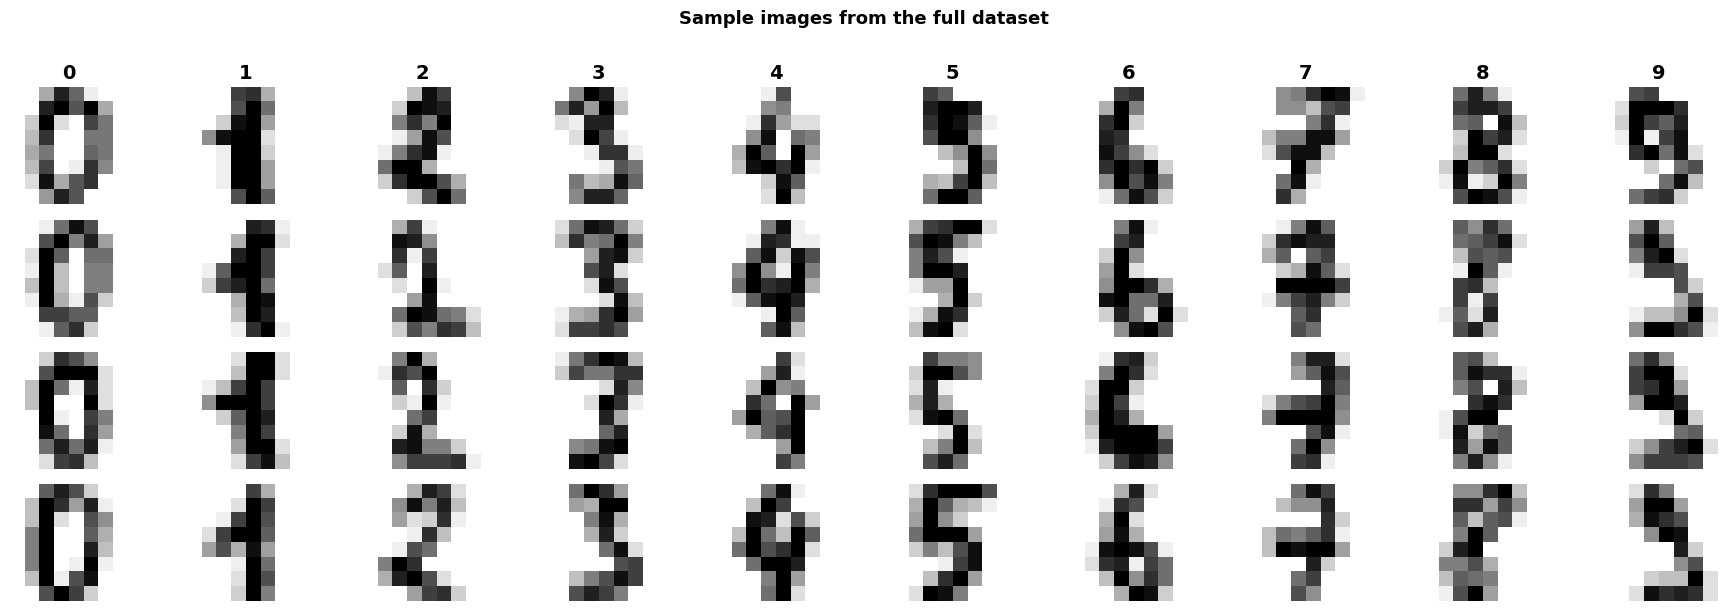

In [3]:
# Let's look at the first 5 patients as a table
from src.plot_examples import plot_example_data

plot_example_data(X_all, y_all, title="Sample images from the full dataset")

---

## Step 3 — Splitting data: training set vs test set

A crucial concept: we **cannot evaluate a model on the same data we trained it on.**  
That would be like testing a student with the exact same exam questions they studied — it doesn't tell you if they truly understood.

So we split:

```
ALL DATA
   ├── TRAINING SET (80%)  ──►  model learns from this
   └── TEST SET    (20%)  ──►  we evaluate on this (model has never seen it)
```

Training set: 1437 patients  ← model learns from these
Test set:     360 patients   ← we use these to evaluate


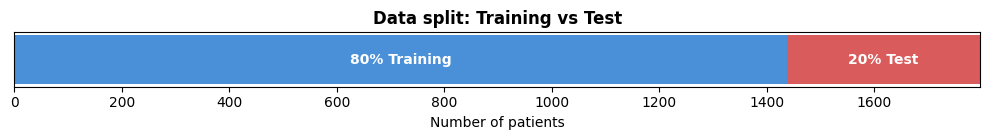


💬 DISCUSS: Why can't we just use all data for training?
            What would happen if we evaluated on training data?


In [4]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {len(X_train)} patients  ← model learns from these")
print(f"Test set:     {len(X_test)} patients   ← we use these to evaluate")

# Visualise the split
fig, ax = plt.subplots(figsize=(10, 1.5))
ax.barh(0, len(X_train), color='#4A90D9', height=0.5, label=f'Training ({len(X_train)})')
ax.barh(0, len(X_test), left=len(X_train), color='#D95B5B', height=0.5, label=f'Test ({len(X_test)})')
ax.set_xlim(0, len(X))
ax.set_yticks([])
ax.set_xlabel('Number of patients')
ax.set_title('Data split: Training vs Test', fontweight='bold')
# ax.legend(loc='upper right')
ax.text(len(X_train)/2, 0, '80% Training', ha='center', va='center', color='white', fontweight='bold')
ax.text(len(X_train) + len(X_test)/2, 0, '20% Test', ha='center', va='center', color='white', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💬 DISCUSS: Why can't we just use all data for training?")
print("            What would happen if we evaluated on training data?")

---

## Step 4 — Train your first model! 🎉

We'll train a **logistic regression** model. It learns a weighted combination of the input features to produce a probability between 0 and 1.

**Training = the model finding the best weights from your training data.**

The whole training process happens in one line of code:

In [5]:
from sklearn import svm

# Create a classifier model
model = svm.SVC(gamma=0.001)

# 🎓 TRAIN THE MODEL — this is where learning happens
model.fit(X_train, y_train)  # ← this one line does all the learning

print("✅ Model trained!")

✅ Model trained!


---

## Step 6 — Make predictions on new patients

Now let's use the model on the **test set** — patients it has never seen before.

For each patient, the model outputs a **probability** (0 to 1), then classifies above 0.5 as benign.

In [6]:
# Get predictions on the test set
y_pred       = model.predict(X_test)           # 0 or 1

# Show the first 10 test patients
print("First 10 test patients:")
print(f"{'Sample':>8} | {'True label':>12} | {'Predicted':>12}  {'Correct?':>9}")
print("-" * 62)
for i in range(10):
    true     = y_test[i] 
    pred     = y_pred[i]
    correct  = '✅' if y_test[i] == y_pred[i] else '❌'
    print(f"{i+1:>8} | {true:>12} | {pred:>12} | {correct:>9}")

print()
print("💬 DISCUSS: Patient 3 has P(benign) = ?")
print("            What does that probability mean clinically?")
print("            Would you act differently for P=0.51 vs P=0.99?")

First 10 test patients:
  Sample |   True label |    Predicted   Correct?
--------------------------------------------------------------
       1 |            6 |            6 |         ✅
       2 |            9 |            9 |         ✅
       3 |            3 |            3 |         ✅
       4 |            7 |            7 |         ✅
       5 |            2 |            2 |         ✅
       6 |            1 |            1 |         ✅
       7 |            5 |            5 |         ✅
       8 |            2 |            2 |         ✅
       9 |            5 |            5 |         ✅
      10 |            2 |            2 |         ✅

💬 DISCUSS: Patient 3 has P(benign) = ?
            What does that probability mean clinically?
            Would you act differently for P=0.51 vs P=0.99?


---

## Step 7 — How good is the model? Evaluating performance

Overall accuracy on test set: 98.9%
(i.e. the model got 356 out of 360 patients correct)



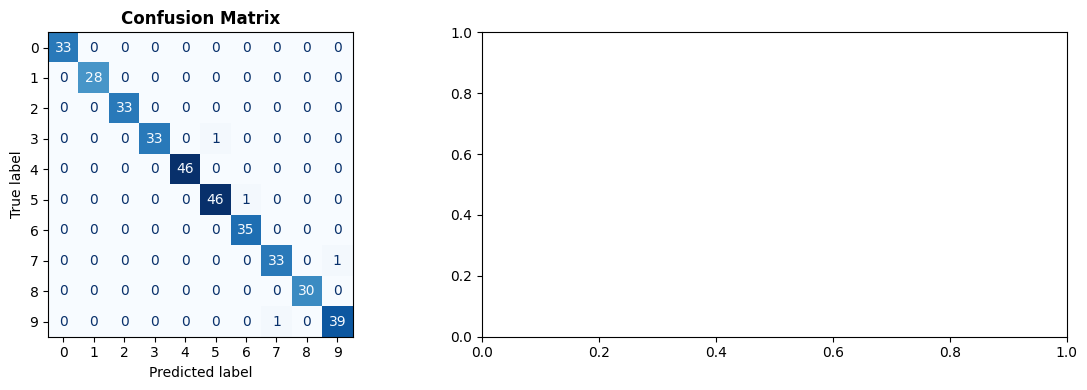

💬 DISCUSS:
  - What is worse: a False Positive or a False Negative? Does it depend on context?
  - What would happen if you moved the decision threshold from 0.5 to 0.3?
  - Is 'accuracy' always a good metric? What if 95% of patients were benign?


In [7]:
# Compute accuracy and show confusion matrix
acc = accuracy_score(y_test, y_pred)
cm  = confusion_matrix(y_test, y_pred)

print(f"Overall accuracy on test set: {acc*100:.1f}%")
print(f"(i.e. the model got {int(acc*len(y_test))} out of {len(y_test)} patients correct)\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- Confusion matrix ---
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# Annotate
# axes[0].text(0, 0, f'\n\nTrue Negative\n(correctly\npredicted malignant)', 
#              ha='center', va='center', fontsize=7, color='navy')
# axes[0].text(1, 0, f'\n\nFalse Positive\n(missed malignant!)', 
#              ha='center', va='center', fontsize=7, color='darkred')
# axes[0].text(0, 1, f'\n\nFalse Negative\n(false alarm)', 
#              ha='center', va='center', fontsize=7, color='darkred')
# axes[0].text(1, 1, f'\n\nTrue Positive\n(correctly\npredicted benign)', 
#              ha='center', va='center', fontsize=7, color='navy')

# --- Probability distribution ---
# benign_probs    = y_pred_proba[y_test == 1]
# malignant_probs = y_pred_proba[y_test == 0]
# axes[1].hist(malignant_probs, bins=15, alpha=0.7, color='#D95B5B', label='True: Malignant')
# axes[1].hist(benign_probs,    bins=15, alpha=0.7, color='#5BA85A', label='True: Benign')
# axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Decision threshold (0.5)')
# axes[1].set_xlabel('Predicted P(benign)')
# axes[1].set_ylabel('Number of patients')
# axes[1].set_title('Model confidence distribution', fontweight='bold')
# axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("💬 DISCUSS:")
print("  - What is worse: a False Positive or a False Negative? Does it depend on context?")
print("  - What would happen if you moved the decision threshold from 0.5 to 0.3?")
print("  - Is 'accuracy' always a good metric? What if 95% of patients were benign?")

---

## Step 8 — 🔬 What happens when you change the training data?

This is the core insight of Block 2. **The model is only as good as the data it was trained on.**

Let's see what happens when we train on *less* data, or *biased* data.

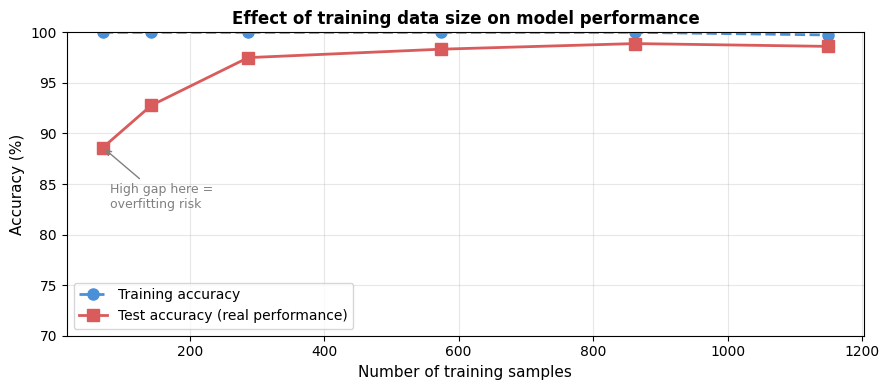

💬 DISCUSS:
  - Why is training accuracy almost always higher than test accuracy?
  - What does the gap between the two lines tell you?
  - In RT, we often have only 50-200 patients for a prediction model. What does this graph suggest?


In [8]:
# Experiment: How does training data size affect performance?
training_fractions = [0.05, 0.10, 0.20, 0.40, 0.60, 0.80]
accuracies_train = []
accuracies_test  = []

for frac in training_fractions:
    X_tr, _, y_tr, _ = train_test_split(X_train, y_train, 
                                         train_size=frac, random_state=42)
    m = svm.SVC(gamma=0.001)
    m.fit(X_tr, y_tr)
    accuracies_train.append(accuracy_score(y_tr,         m.predict(X_tr)))
    accuracies_test.append( accuracy_score(y_test,       m.predict(X_test)))

n_patients = [int(f * len(X_train)) for f in training_fractions]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(n_patients, [a*100 for a in accuracies_train], 'o--', color='#4A90D9', 
        linewidth=2, markersize=8, label='Training accuracy')
ax.plot(n_patients, [a*100 for a in accuracies_test],  's-',  color='#D95B5B', 
        linewidth=2, markersize=8, label='Test accuracy (real performance)')
ax.set_xlabel('Number of training samples', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Effect of training data size on model performance', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(70, 100)
ax.grid(alpha=0.3)

# Annotate overfitting region
ax.annotate('High gap here =\noverfitting risk',
            xy=(n_patients[0], accuracies_test[0]*100),
            xytext=(n_patients[0]+10, accuracies_test[0]*100 - 6),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("💬 DISCUSS:")
print("  - Why is training accuracy almost always higher than test accuracy?")
print("  - What does the gap between the two lines tell you?")
print("  - In RT, we often have only 50-200 patients for a prediction model. What does this graph suggest?")

In [9]:
# Experiment: What if training data is biased (only one type of patient)?
# Simulate: train only on patients with small tumours (radius < median)
median_radius = np.median(X_train[:, 0])  # feature 0 = mean radius

# Biased training set: only small tumours
bias_mask = X_train[:, 0] < median_radius
X_biased = X_train_scaled[bias_mask]
y_biased = y_train[bias_mask]

model_biased = LogisticRegression(random_state=42)
model_biased.fit(X_biased, y_biased)

# Compare on ALL test patients vs only large tumour test patients
acc_biased_all   = accuracy_score(y_test, model_biased.predict(X_test_scaled))
acc_original_all = accuracy_score(y_test, model.predict(X_test_scaled))

# Large tumour patients in test set
large_mask_test = X_test[:, 0] >= median_radius
acc_biased_large   = accuracy_score(y_test[large_mask_test], 
                                     model_biased.predict(X_test_scaled[large_mask_test]))
acc_original_large = accuracy_score(y_test[large_mask_test], 
                                     model.predict(X_test_scaled[large_mask_test]))

print("Model performance comparison:")
print(f"\n{'':35} {'Original model':>16} {'Biased model':>14}")
print("-" * 68)
print(f"{'Trained on':35} {'all patients':>16} {'small tumours only':>14}")
print(f"{'Training patients':35} {len(X_train):>16} {len(X_biased):>14}")
print()
print(f"{'Accuracy on ALL test patients':35} {acc_original_all*100:>15.1f}% {acc_biased_all*100:>13.1f}%")
print(f"{'Accuracy on LARGE tumour patients':35} {acc_original_large*100:>15.1f}% {acc_biased_large*100:>13.1f}%")

print()
print("💬 DISCUSS:")
print("  - Why does the biased model perform worse on large tumour patients?")
print("  - In RT, what would a 'biased training dataset' look like in practice?")
print("    (Think: proton centre data, single-institution data, one CT scanner...)")

NameError: name 'X_train_scaled' is not defined

---

## Step 9 — 🌳 A different kind of model: Decision Tree

Logistic regression is just one type of model. Let's train a **decision tree** on the same data — it makes decisions using a series of yes/no questions, just like a flowchart.

This is useful for understanding that *a model is a function learned from data* — the form it takes can vary a lot.

Decision Tree accuracy:     94.7%
Logistic Regression accuracy: 97.4%

Both are trained on the same data and solve the same task.
The 'model' is just the type of function we chose to learn from data.


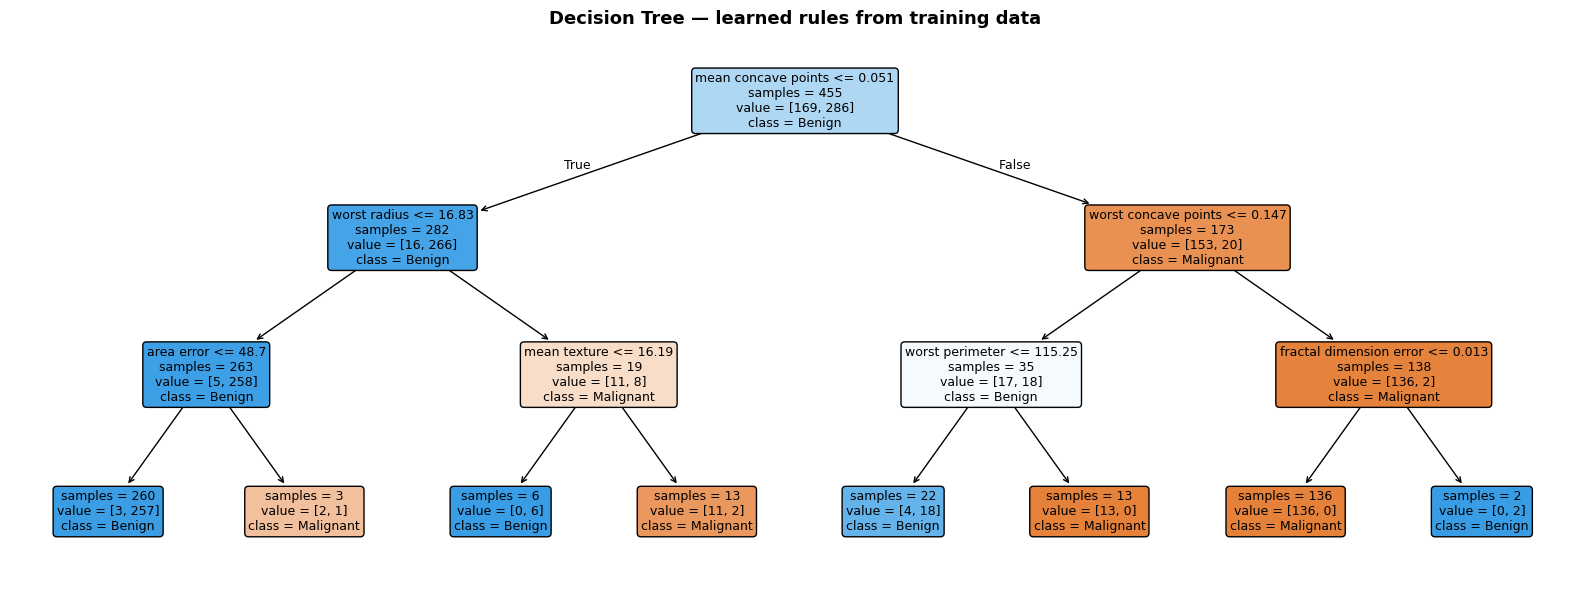

💬 DISCUSS:
  - Can you read the first decision? What does the tree check first?
  - Do these rules look clinically reasonable?
  - Would you trust this tree's rules for a patient very different from the training data?


In [ ]:
# Train a small decision tree (limited depth so we can visualise it)
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)  # trees don't need scaling

acc_tree = accuracy_score(y_test, tree_model.predict(X_test))
acc_logr = accuracy_score(y_test, model.predict(X_test_scaled))

print(f"Decision Tree accuracy:     {acc_tree*100:.1f}%")
print(f"Logistic Regression accuracy: {acc_logr*100:.1f}%")
print()
print("Both are trained on the same data and solve the same task.")
print("The 'model' is just the type of function we chose to learn from data.")

# Visualise the tree
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree_model, 
          feature_names=data.feature_names,
          class_names=['Malignant', 'Benign'],
          filled=True, rounded=True, fontsize=9, ax=ax,
          impurity=False, proportion=False)
ax.set_title('Decision Tree — learned rules from training data', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("💬 DISCUSS:")
print("  - Can you read the first decision? What does the tree check first?")
print("  - Do these rules look clinically reasonable?")
print("  - Would you trust this tree's rules for a patient very different from the training data?")

---

## Step 10 — 🧠 Apply this to RT: a conceptual map

Everything you just did maps directly to AI in your clinic:

In [ ]:
from IPython.display import HTML

table = """
<style>
  .rt-map { border-collapse:collapse; width:100%; font-family:'Segoe UI',sans-serif; font-size:13px; }
  .rt-map th { background:#2C3E7A; color:white; padding:10px 14px; text-align:left; }
  .rt-map td { padding:10px 14px; border-bottom:1px solid #ddd; vertical-align:top; }
  .rt-map tr:nth-child(even) td { background:#f4f6ff; }
  .concept { font-weight:bold; color:#2C3E7A; }
</style>
<h3 style='font-family:Segoe UI;color:#1a1a2e'>From this notebook → your clinic</h3>
<table class='rt-map'>
  <tr><th>Concept you just used</th><th>In RT auto-segmentation</th><th>In RT prediction model</th></tr>
  <tr>
    <td class='concept'>Input (features)</td>
    <td>CT voxel intensities (3D image)</td>
    <td>Patient & plan features (DVH, age, tumour site…)</td>
  </tr>
  <tr>
    <td class='concept'>Output (label)</td>
    <td>Binary mask: which voxel belongs to which structure</td>
    <td>Toxicity probability / treatment response score</td>
  </tr>
  <tr>
    <td class='concept'>Ground truth</td>
    <td>Manual contours by radiation oncologist</td>
    <td>Observed clinical outcome (e.g. grade ≥2 xerostomia)</td>
  </tr>
  <tr>
    <td class='concept'>Training set</td>
    <td>Historical CT scans with approved contours</td>
    <td>Previously treated patients with known outcomes</td>
  </tr>
  <tr>
    <td class='concept'>Test set</td>
    <td>Held-out cases from same/different institution</td>
    <td>Held-out patients, or prospective validation cohort</td>
  </tr>
  <tr>
    <td class='concept'>Model</td>
    <td>Neural network (e.g. U-Net) with millions of weights</td>
    <td>Logistic regression, neural network, random forest</td>
  </tr>
  <tr>
    <td class='concept'>Biased training data</td>
    <td>Trained only on one scanner / one institution / one guideline</td>
    <td>Trained only on photon patients → applied to proton</td>
  </tr>
  <tr>
    <td class='concept'>Evaluation metric</td>
    <td>Dice Similarity Coefficient, Hausdorff distance</td>
    <td>AUC, calibration, sensitivity/specificity</td>
  </tr>
</table>
"""
display(HTML(table))

Concept you just used,In RT auto-segmentation,In RT prediction model
Input (features),CT voxel intensities (3D image),"Patient & plan features (DVH, age, tumour site…)"
Output (label),Binary mask: which voxel belongs to which structure,Toxicity probability / treatment response score
Ground truth,Manual contours by radiation oncologist,Observed clinical outcome (e.g. grade ≥2 xerostomia)
Training set,Historical CT scans with approved contours,Previously treated patients with known outcomes
Test set,Held-out cases from same/different institution,"Held-out patients, or prospective validation cohort"
Model,Neural network (e.g. U-Net) with millions of weights,"Logistic regression, neural network, random forest"
Biased training data,Trained only on one scanner / one institution / one guideline,Trained only on photon patients → applied to proton
Evaluation metric,"Dice Similarity Coefficient, Hausdorff distance","AUC, calibration, sensitivity/specificity"


---

## 🏁 Summary

In this notebook you:

1. ✅ Loaded a **dataset** with inputs (measurements) and outputs (labels)
2. ✅ Split it into a **training set** and a **test set**
3. ✅ **Trained a model** — the model learned a function from the training data
4. ✅ Used the model to **make predictions** on unseen patients
5. ✅ **Evaluated** the model and saw where it made mistakes
6. ✅ Observed that **less data** and **biased data** hurt performance
7. ✅ Saw that different **model types** (logistic regression, decision tree) can solve the same problem

---

### ➡️ In Block 2 we'll go deeper:
*How is model quality reported in literature? When can you trust the numbers? And what happens when a deployed model starts to fail?*